In [ ]:
import tensorflow as tf
import os
import numpy as np
from sklearn.metrics import matthews_corrcoef, precision_score, recall_score, accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import Model

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PATH = '/content/drive/MyDrive/'

## AVERAGE BASED WEIGHTING VOTING // AVERAGE SCORE WEIGHTED AVERAGE

In [ ]:
def average_voting(model_probabilities):
  avg = 0
  for probs in model_probabilities:
    avg += probs
  avg = avg / len(model_probabilities)
  print("----AV COMPLETED----")
  return avg

def majority_voting(model_probabilities):
  mv = 0
  for probs in model_probabilities:
    mv += probs
  mv = mv / len(model_probabilities)
  print("----MV COMPLETED----")
  return np.round(mv)

In [ ]:
def metric_models(modelos_o_preds, metric = 'prec', X_val=None, y_val=None):
    accuracies = {}

    if len(y_val.shape) > 1 and y_val.shape[1] > 1:
        y_val = np.argmax(y_val, axis=1)

    for i, item in enumerate(modelos_o_preds):
        if callable(getattr(item, "predict", None)):
            predicts = np.argmax(item.predict(X_val, verbose = 0), axis=1)
        else:
            predicts = item

        if metric == 'prec':
          measure = precision_score(y_val, predicts)
        elif metric == 'acc':
          measure = accuracy_score(y_val, predicts)
        elif metric == 'recall':
          measure = recall_score(y_val, predicts)
        elif metric == 'f1':
          measure = f1_score(y_val, predicts)
        elif metric == 'mcc':
          measure = matthews_corrcoef(y_val, predicts)
        elif metric == 'combined':
          measure = matthews_corrcoef(y_val, predicts)* f1_score(y_val, predicts) +  recall_score(y_val, predicts)
        else:
          raise NameError("Metric specified should be one of the following: acc, prec, recall, f1, mcc")
        accuracies[f"Modelo_{i+1}"] = measure

    return accuracies

In [ ]:
def average_weighted_voting_exponential(models, X_val, Y_val, metric='prec'):

  all_are_models = all(hasattr(item, "predict") and callable(item.predict) for item in models)

  if all_are_models:
    accuracies = metric_models(models, metric, X_val, Y_val)
    accuracies2 = np.array(list(accuracies.values()))
    alpha = np.exp(-10 * (1 - accuracies2))
    alpha /= np.sum(alpha)
    preds_probas = [model.predict(X_val, verbose=0) for model in models]

  else:
    binary_targets = [np.argmax(preds, axis=1) for preds in models]
    accuracies = metric_models(binary_targets, metric, X_val, Y_val)
    accuracies2 = np.array(list(accuracies.values()))
    alpha = np.exp(-10 * (1 - accuracies2))
    alpha /= np.sum(alpha)
    preds_probas = models

  weighted_preds = np.zeros_like(preds_probas[0])
  for i, preds in enumerate(preds_probas):
    weighted_preds += preds * alpha[i]

  final_preds = weighted_preds
  print("----ABWVe COMPLETED----")
  print("NORMALIZED WEIGHTS: ", alpha)

  return final_preds

In [ ]:
def abwv_ensemble(models, X_val, Y_val, metric = 'prec'):

    all_are_models = all(hasattr(item, "predict") and callable(item.predict) for item in models)

    if all_are_models:
      accuracies = metric_models(models, metric, X_val, Y_val)
      weights = np.array(list(accuracies.values()))
      weights = weights / np.sum(weights) 
      preds_probas = [model.predict(X_val, verbose=0) for model in models]

    else:
      binary_targets = [np.argmax(preds, axis=1) for preds in models]
      accuracies = metric_models(binary_targets, metric, X_val, Y_val)
      weights = np.array(list(accuracies.values()))
      weights = weights / np.sum(weights) 
      preds_probas = models

    weighted_preds = np.zeros_like(preds_probas[0])  
    for i, preds in enumerate(preds_probas):
        weighted_preds += preds * weights[i]  
    final_preds = weighted_preds
    print("----ABWV COMPLETED----")
    print("NORMALIZED WEIGHTS: ", weights)

    return final_preds

In [ ]:
def extract_features(model, X,  ln=-3):
    feature_extractor = Model(inputs=model.input, outputs=model.layers[ln].output) 
    print("EXTRACTED FEATURES FROM LAYER", model.layers[ln].name )
    return feature_extractor.predict(X, verbose=0)

## Ensemble in OCT module

In [ ]:
# Previously trained model loading (CNN, STACKING WITH SVM, CNN + UPPER MLP)

# CNN INDIVIDUALS
RESNET50 = os.path.join(PATH, 'OCT_RESNET50.keras')
MOBILENET = os.path.join(PATH, 'OCT_MOBILENETV3LARGE.keras')
XCEPTION = os.path.join(PATH, 'OCT_XCEPTION.keras')

model1_oct =  tf.keras.models.load_model(RESNET50)
model2_oct =  tf.keras.models.load_model(MOBILENET)
model3_oct =  tf.keras.models.load_model(XCEPTION)

# STACKING  SVM
# meta_model_oct = joblib.load('/content/drive/My Drive/OCT_SVM.pkl')

#  CNN + MLP
# MLP_OCT = os.path.join(PATH, 'OCT_MLP.keras')
# MLP_oct =  tf.keras.models.load_model(MLP_OCT)

In [ ]:
external_dir = os.path.join(PATH, 'TRAINING OCT/EXTERNAL VALIDATION/AFIO/DUAL IMAGES/OCT')

BATCH_SIZE = 16
img_dim = 224
IMG_SIZE = (img_dim, img_dim)

external_dataset_oct = tf.keras.utils.image_dataset_from_directory(external_dir,
                                                                 shuffle=False,
                                                                 batch_size=BATCH_SIZE,
                                                                #  class_names=["normal", "glaucoma"],
                                                                 image_size=IMG_SIZE,
                                                                 label_mode = 'categorical'
                                                                 )

class_names = external_dataset_oct.class_names
print(class_names)

Found 38 files belonging to 2 classes.
['glaucoma', 'normal']


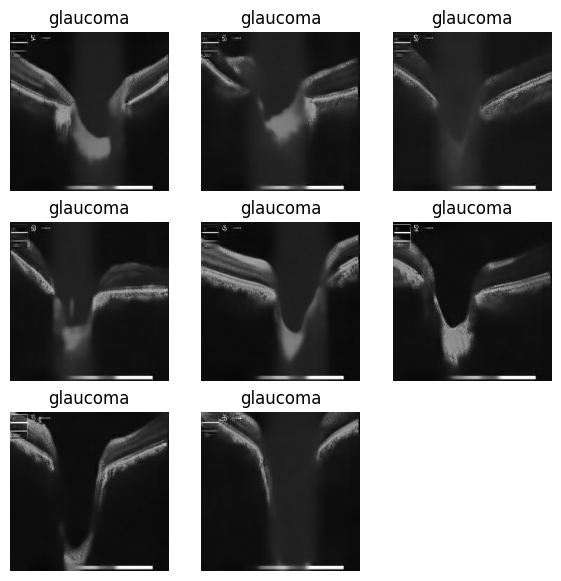

In [ ]:
plt.figure(figsize=(7, 7))
for images, labels in external_dataset_oct.take(1):
  for i in range(8):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    class_index = np.argmax(labels[i].numpy()) 
    plt.title(class_names[class_index])
    plt.axis("off")

In [ ]:
y_external = []
X_external = []

for images, labels in external_dataset_oct:
    X_external.append(images)
    y_external.append(labels)

X_external_oct = np.concatenate(X_external)
y_external_oct = np.concatenate(y_external)

In [ ]:
# Base model predictions on external set
pred1_oct = model1_oct.predict(X_external_oct, verbose = 0)
pred2_oct = model2_oct.predict(X_external_oct, verbose = 0)
pred3_oct = model3_oct.predict(X_external_oct, verbose = 0)

In [ ]:
# features extraction for stacking 

# features1_oct = extract_features(model1_oct, X_external_oct)
# features2_oct = extract_features(model2_oct, X_external_oct)
# features3_oct = extract_features(model3_oct, X_external_oct)

In [ ]:
predictions = [pred2_oct, pred3_oct]
models = [model2_oct, model3_oct]
# features = [features1_oct, features2_oct, features3_oct]
# Average voting
AV_OCT = average_voting(predictions)
# Majority voting
MV_OCT = majority_voting(predictions)
# Average Based Weighting Voting (ABWV)
ABWV_OCT = abwv_ensemble(models, X_external_oct, y_external_oct)
# Average Based Weighting Voting (ABWV) versión exponencial
ABWVe_OCT = average_weighted_voting_exponential(models, X_external_oct, y_external_oct)

# Stacking


# X_meta_model_oct = np.concatenate(features, axis=1)
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_meta_model_oct_scaled = scaler.fit_transform(X_meta_model_oct)

# Stacking_meta_model_oct_proba = meta_model_oct.predict_proba(X_meta_model_oct_scaled)




# MLP


# MLP = MLP_oct.predict(X_external_oct)
# model_oct = model3_oct.predict(X_external_oct)

----CÁLCULO DE AV COMPLETADO----
----CÁLCULO DE MV COMPLETADO----
----CÁLCULO DE ABWV COMPLETADO----
PESOS NORMALIZADOS:  [0.48648649 0.51351351]
----CÁLCULO DE ABWVe COMPLETADO----
PESOS NORMALIZADOS:  [0.37137658 0.62862342]


In [ ]:
model_oct = ABWV_OCT # Change here to select ensemble method
etiquetas_predichas_oct = (model_oct > 0.5).astype(int)

etiquetas_predichas_int = np.argmax(etiquetas_predichas_oct, axis=1)
y_test_int = np.argmax(y_external_oct, axis=1)

In [ ]:
mcc = matthews_corrcoef(etiquetas_predichas_int, y_test_int)
precision = precision_score(etiquetas_predichas_int, y_test_int, average='macro')*100
recall = recall_score(etiquetas_predichas_int, y_test_int, average='macro')*100
exactitud = accuracy_score(etiquetas_predichas_int, y_test_int)*100
f1 = f1_score(etiquetas_predichas_int, y_test_int, average='macro')*100

print("Matthews Correlation Coefficient (MCC):", mcc)
print("Precision: {:.2f} %".format(precision))
print("Recall: {:.2f} %".format(recall))
print("Accuracy: {:.2f} %".format(exactitud))
print("F1-score: {:.2f} %".format(f1))

Coeficiente de correlación de Mathews (MCC): 0.6183239636408276
Precisión: 81.45 %
Recall: 80.39 %
Exactitud: 78.95 %
F1-score: 78.89 %


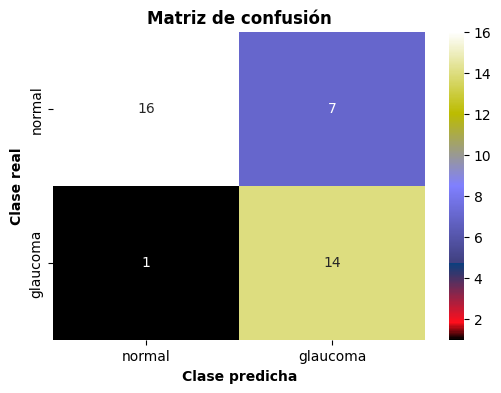

In [ ]:
cm = confusion_matrix(y_test_int, etiquetas_predichas_int)
cm_custom = np.array([[cm[1,1], cm[1,0]],   # TP, FN
                      [cm[0,1], cm[0,0]]])  # FP, TN
plt.figure(figsize=(6, 4))
sns.heatmap(cm_custom, annot=True, fmt="d", cmap="gist_stern", cbar=True,  xticklabels=class_names[::-1], yticklabels=class_names[::-1])
plt.xlabel("Predicted class", fontweight='bold')
plt.ylabel("Real class", fontweight='bold')
plt.title("Confusion Matrix",fontweight='bold', fontsize = 12)
plt.show()

In [ ]:
report_ext = classification_report(y_test_int, etiquetas_predichas_int, target_names=class_names)
print(report_ext)

              precision    recall  f1-score   support

    glaucoma       0.67      0.93      0.78        15
      normal       0.94      0.70      0.80        23

    accuracy                           0.79        38
   macro avg       0.80      0.81      0.79        38
weighted avg       0.83      0.79      0.79        38



In [ ]:
y_pred_prob = model_oct
AUC = roc_auc_score(y_external_oct, y_pred_prob)
AUC_macro = roc_auc_score(y_external_oct, y_pred_prob, average="macro", multi_class="ovr")

print(f"AUC One-vs-Rest: {AUC:.4f}")
print(f"AUC Macro: {AUC_macro:.4f}")

fpr, tpr, THRESOLD_EXTERNAL = roc_curve(y_external_oct[:, 0], y_pred_prob[:, 0])
roc_auc = auc(fpr, tpr)

J_scores = tpr - fpr  # Sensibilidad - (1 - Especificidad)
best_threshold = THRESOLD_EXTERNAL[np.argmax(J_scores)]

print(f"Best threshold based on ROC curve: {best_threshold:.3f}")

AUC One-vs-Rest: 0.9507
AUC Macro: 0.9507
Mejor umbral basado en la curva ROC: 0.718


## Ensemble in CFP module

In [ ]:
external_dir = os.path.join(PATH, 'TRAINING CFP/EXTERNAL VALIDATION/AFIO/DUAL IMAGES/CFP')

BATCH_SIZE = 16
img_dim = 224
IMG_SIZE = (img_dim, img_dim)

external_dataset_cfp = tf.keras.utils.image_dataset_from_directory(external_dir,
                                                                 shuffle=False,
                                                                #  class_names=["normal", "glaucoma"],
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE,
                                                                 label_mode = 'categorical'
                                                                 )

class_names = external_dataset_cfp.class_names
print(class_names)

Found 38 files belonging to 2 classes.
['glaucoma', 'normal']


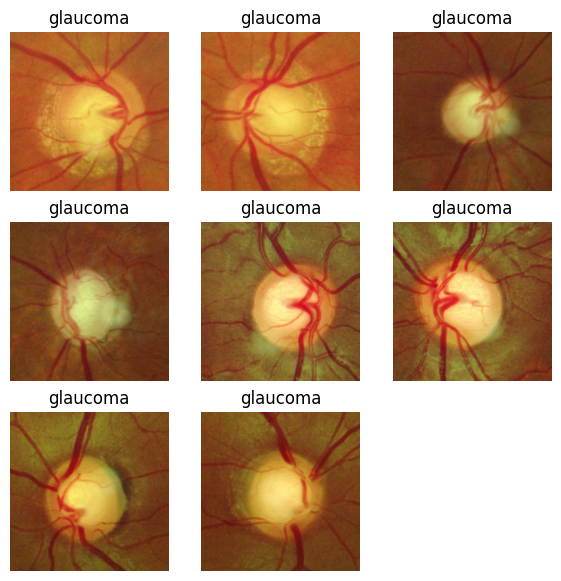

In [ ]:
plt.figure(figsize=(7, 7))
for images, labels in external_dataset_cfp.take(1):
  for i in range(8):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    class_index = np.argmax(labels[i].numpy()) 
    plt.title(class_names[class_index])
    plt.axis("off")

In [ ]:
PATH = '/content/drive/MyDrive/'

RESNET50 = os.path.join(PATH, 'CFP_RESNET50.keras')
INCEPTIONV3 = os.path.join(PATH, 'CFP_INCEPTIONV3.keras')
DENSENET = os.path.join(PATH, 'CFP_DENSENET169.keras')

model1_cfp =  tf.keras.models.load_model(RESNET50)
model2_cfp =  tf.keras.models.load_model(INCEPTIONV3)
model3_cfp = tf.keras.models.load_model(DENSENET)

# Stacking SVM

# meta_model_cfp = joblib.load('/content/drive/My Drive/CFP_SVM.pkl')



# MLP

# MLP_CFP = os.path.join(PATH, 'CFP_MLPVkeras')
# MLP_cfp =  tf.keras.models.load_model(MLP_CFP)

In [ ]:
y_external = []
X_external = []

for images, labels in external_dataset_cfp:
    X_external.append(images)
    y_external.append(labels)

X_external_cfp = np.concatenate(X_external)
y_external_cfp = np.concatenate(y_external)

In [ ]:
pred1_cfp = model1_cfp.predict(external_dataset_cfp, verbose = 0)
pred2_cfp = model2_cfp.predict(external_dataset_cfp, verbose = 0)
pred3_cfp = model3_cfp.predict(external_dataset_cfp, verbose = 0)

In [ ]:
# features1_cfp = extract_features(model1_cfp, X_external_cfp)
# features2_cfp = extract_features(model2_cfp, X_external_cfp)
# features3_cfp = extract_features(model3_cfp, X_external_cfp)

In [ ]:
predictions = [pred1_cfp,pred2_cfp]
models = [model1_cfp, model2_cfp]
# features = [features1_cfp, features2_cfp, features3_cfp]

# Average voting
AV_CFP = average_voting(predictions)
# Majority voting
MV_CFP = majority_voting(predictions)
# Average Based Weighting Voting (ABWV)
ABWV_CFP = abwv_ensemble(models, X_external_cfp, y_external_cfp)
# Average Based Weighting Voting (ABWV) versión exponencial
ABWVe_CFP = average_weighted_voting_exponential(models, X_external_cfp, y_external_cfp)

# STACKING


# X_meta_model_cfp = np.concatenate(features, axis=1)
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_meta_model_cfp_scaled = scaler.fit_transform(X_meta_model_cfp)
# Stacking_meta_model_cfp_proba = meta_model_cfp.predict_proba(X_meta_model_cfp_scaled)



# MLP


# MLP = MLP_cfp.predict(X_external_cfp)

----CÁLCULO DE AV COMPLETADO----
----CÁLCULO DE MV COMPLETADO----
----CÁLCULO DE ABWV COMPLETADO----
PESOS NORMALIZADOS:  [0.51030928 0.48969072]
----CÁLCULO DE ABWVe COMPLETADO----
PESOS NORMALIZADOS:  [0.59454225 0.40545775]


In [ ]:
model_cfp = ABWV_CFP

etiquetas_predichas_cfp = (model_cfp > 0.5).astype(int)

etiquetas_predichas_int = np.argmax(etiquetas_predichas_cfp, axis=1)
y_test_int = np.argmax(y_external_cfp, axis=1)

In [ ]:
mcc = matthews_corrcoef(etiquetas_predichas_int, y_test_int)
precision = precision_score(etiquetas_predichas_int, y_test_int, average='macro')*100
recall = recall_score(etiquetas_predichas_int, y_test_int, average='macro')*100
exactitud = accuracy_score(etiquetas_predichas_int, y_test_int)*100
f1 = f1_score(etiquetas_predichas_int, y_test_int, average='macro')*100

print("Matthews Correlation Coefficient (MCC):", mcc)
print("Precision: {:.2f} %".format(precision))
print("Recall: {:.2f} %".format(recall))
print("Accuracy: {:.2f} %".format(exactitud))
print("F1-score: {:.2f} %".format(f1))

Coeficiente de correlación de Mathews (MCC): 0.7288746356672758
Precisión: 86.81 %
Recall: 86.08 %
Exactitud: 86.84 %
F1-score: 86.38 %


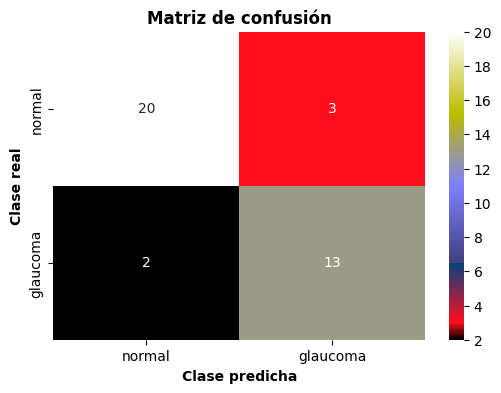

In [ ]:
cm = confusion_matrix(y_test_int, etiquetas_predichas_int)
cm_custom = np.array([[cm[1,1], cm[1,0]],   # TP, FN
                      [cm[0,1], cm[0,0]]])  # FP, TN
plt.figure(figsize=(6, 4))
sns.heatmap(cm_custom, annot=True, fmt="d", cmap="gist_stern", cbar=True,  xticklabels=class_names[::-1], yticklabels=class_names[::-1])
plt.xlabel("Predicted class", fontweight='bold')
plt.ylabel("Real class", fontweight='bold')
plt.title("COnfusion Matrix",fontweight='bold', fontsize = 12)
plt.show()

In [ ]:
report_ext = classification_report(y_test_int, etiquetas_predichas_int, target_names=class_names)
print(report_ext)

              precision    recall  f1-score   support

    glaucoma       0.81      0.87      0.84        15
      normal       0.91      0.87      0.89        23

    accuracy                           0.87        38
   macro avg       0.86      0.87      0.86        38
weighted avg       0.87      0.87      0.87        38



In [ ]:
y_pred_prob = model_cfp
AUC = roc_auc_score(y_external_cfp, y_pred_prob)
AUC_macro = roc_auc_score(y_external_cfp, y_pred_prob, average="macro", multi_class="ovr")

print(f"AUC One-vs-Rest: {AUC:.4f}")
print(f"AUC Macro: {AUC_macro:.4f}")

fpr, tpr, THRESOLD_EXTERNAL = roc_curve(y_external_cfp[:, 0], y_pred_prob[:, 0])
roc_auc = auc(fpr, tpr)

J_scores = tpr - fpr  # Sensibilidad - (1 - Especificidad)
best_threshold = THRESOLD_EXTERNAL[np.argmax(J_scores)]

print(f"Best threshold based on ROC curve: {best_threshold:.3f}")

AUC One-vs-Rest: 0.9333
AUC Macro: 0.9333
Mejor umbral basado en la curva ROC: 0.760


## Joint model (OCT + CFP)

In [ ]:
model_cfp = ABWV_CFP
model_oct = ABWV_OCT

In [ ]:
# Weighted Average Ensemble
weight_module_1 = 0.6
weight_module_2 = 0.4

final_probs = (weight_module_1 * model_cfp) + (weight_module_2 * model_oct)


In [ ]:
etiquetas_predichas = (final_probs > 0.5).astype(int)

etiquetas_predichas_int = np.argmax(etiquetas_predichas, axis=1)
y_test_int = np.argmax(y_external_cfp, axis=1)

In [ ]:
mcc = matthews_corrcoef(etiquetas_predichas_int, y_test_int)
precision = precision_score(etiquetas_predichas_int, y_test_int, average='macro')*100
recall = recall_score(etiquetas_predichas_int, y_test_int, average='macro')*100
exactitud = accuracy_score(etiquetas_predichas_int, y_test_int)*100
f1 = f1_score(etiquetas_predichas_int, y_test_int, average='macro')*100

print("Matthews Correlation Coefficient (MCC):", mcc)
print("Precision: {:.2f} %".format(precision))
print("Recall: {:.2f} %".format(recall))
print("Accuracy: {:.2f} %".format(exactitud))
print("F1-score: {:.2f} %".format(f1))

Coeficiente de correlación de Mathews (MCC): 0.8512565307587486
Precisión: 93.48 %
Recall: 91.67 %
Exactitud: 92.11 %
F1-score: 91.97 %


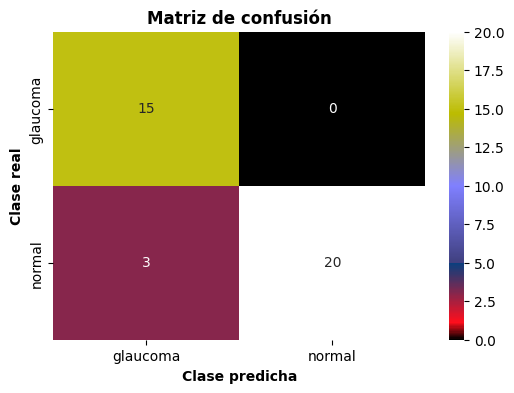

In [ ]:
cm = confusion_matrix(y_test_int, etiquetas_predichas_int)
cm_custom = np.array([[cm[0,0], cm[0,1]],   # TP, FN
                      [cm[1,0], cm[1,1]]])  # FP, TN
plt.figure(figsize=(6, 4))
sns.heatmap(cm_custom, annot=True, fmt="d", cmap="gist_stern", cbar=True,  xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted class", fontweight='bold')
plt.ylabel("Real class", fontweight='bold')
plt.title("Confusion Matrix",fontweight='bold', fontsize = 12)
plt.show()

In [ ]:
report_ext = classification_report(y_test_int, etiquetas_predichas_int, target_names=class_names)
print(report_ext)

              precision    recall  f1-score   support

    glaucoma       0.83      1.00      0.91        15
      normal       1.00      0.87      0.93        23

    accuracy                           0.92        38
   macro avg       0.92      0.93      0.92        38
weighted avg       0.93      0.92      0.92        38



In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc

In [ ]:
y_pred_prob = final_probs
AUC = roc_auc_score(y_external_cfp, y_pred_prob)
AUC_macro = roc_auc_score(y_external_cfp, y_pred_prob, average="macro", multi_class="ovr")

print(f"AUC One-vs-Rest: {AUC:.4f}")
print(f"AUC Macro: {AUC_macro:.4f}")

fpr, tpr, THRESOLD_EXTERNAL = roc_curve(y_external_cfp[:, 0], y_pred_prob[:, 0])
roc_auc = auc(fpr, tpr)

J_scores = tpr - fpr  # Sensibilidad - (1 - Especificidad)
best_threshold = THRESOLD_EXTERNAL[np.argmax(J_scores)]

print(f"Best threshold based on ROC curve: {best_threshold:.3f}")

AUC One-vs-Rest: 0.9652
AUC Macro: 0.9652
Mejor umbral basado en la curva ROC: 0.515


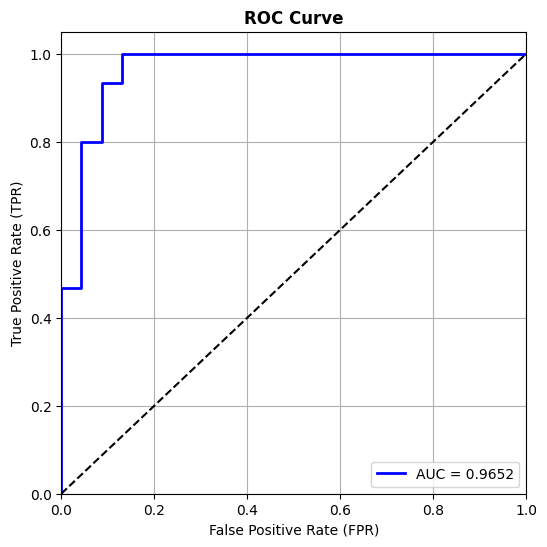

In [ ]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
file_paths = external_dataset_cfp.file_paths
image_names = [path.split("/")[-1] for path in file_paths]
image_names = np.array(image_names)
clase = 1
mascara = (etiquetas_predichas_int != y_test_int) & (y_test_int == clase) 

for name, pred, label, cfp, oct in zip(image_names[mascara], final_probs[mascara], y_external_cfp[mascara], model_cfp[mascara], model_oct[mascara]):
  print(f"Caso: {name}, Pred: {class_names[np.argmax(pred)]}, Real: {class_names[np.argmax(label)]}, Final: {np.max(pred)*100:.2f} % CFP: {class_names[np.argmax(cfp)]} {np.max(cfp)*100:.2f}%, OCT: {class_names[np.argmax(oct)]} {np.max(oct)*100:.2f} %")


Caso: img_0017.png, Pred: glaucoma, Real: normal, Final: 52.93 % CFP: normal 71.84%, OCT: glaucoma 90.09 %
Caso: img_0018.png, Pred: glaucoma, Real: normal, Final: 58.65 % CFP: glaucoma 56.18%, OCT: glaucoma 62.37 %
Caso: img_0024.png, Pred: glaucoma, Real: normal, Final: 86.32 % CFP: glaucoma 98.99%, OCT: glaucoma 67.32 %
Caso: img_0027.png, Pred: glaucoma, Real: normal, Final: 65.56 % CFP: glaucoma 62.56%, OCT: glaucoma 70.06 %
Caso: img_0033.png, Pred: glaucoma, Real: normal, Final: 84.91 % CFP: glaucoma 77.08%, OCT: glaucoma 96.66 %


## GradCam

In [ ]:
def compute_gradcam(img, gradcam_model):

    with tf.GradientTape() as tape:
        tape.watch(img)
        conv_output, pred = gradcam_model(img, training=False)
        pred_idx = tf.argmax(pred[0])
        class_channel = pred[:, pred_idx]

    grads = tape.gradient(class_channel, conv_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]

    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return (heatmap, pred)

In [ ]:
# auto adjust number of row,col (subplot) based on n figures
def auto_plot_fig_data(num_figures, verbose=True, fig_scale=2):
    num_cols = int((num_figures)**(1/2))
    num_rows = num_figures // num_cols
    if num_figures % num_cols != 0: num_rows += 1
    if 5 > num_cols < num_rows:
        num_rows, num_cols = num_cols, num_rows
    w = num_cols * fig_scale
    h = num_rows * fig_scale
    if verbose:
        print(f"num_figures: {num_figures}")
        print(f"(num_cols, num_rows): {(num_cols, num_rows)}")
    return {
        "num_cols": num_cols,
        "num_rows": num_rows,
        "w": w,
        "h": h
    }

In [ ]:
def visualize_gradcam(tfdata, gradcam_model, class_names, verbose=True):
    num_figures = sum([1 for _ in tfdata])
    fd = auto_plot_fig_data(num_figures, verbose)
    num_cols = fd['num_cols']
    num_rows = fd['num_rows']

    plt.figure(figsize=(fd['w'], fd['h']))

    for i, (image, label) in enumerate(tfdata):
        plt.subplot(num_rows, num_cols, i+1)

        #Iterate over the batch dimension
        for single_image, single_label in zip(image, label):
            image_tensor = tf.expand_dims(single_image, axis=0)  
            heat_map, pred = compute_gradcam(image_tensor, gradcam_model)
            heat_map = tf.expand_dims(heat_map, axis=-1)  # Assuming Z is 3 for (224, 224, 3) images
            heat_map = tf.image.resize(heat_map, (224, 224))

            # pred = 1 - pred 

            plt.imshow(single_image.numpy().astype('uint8'))
            plt.imshow(heat_map, cmap='jet', alpha=0.4)
            plt.title(f"Label: {class_names[np.argmax(single_label)]}\nPred: {class_names[np.argmax(pred)]}\nProb: {np.max(pred)*100:.2f}%", fontsize = 11)
            plt.axis("off")
    plt.tight_layout()

In [ ]:
def visualize_cases_heatmaps(cfpdata, octdata, gradcam_model_cfp, gradcam_model_oct, class_names, verbose=True, img_names = image_names):

    cfp_list = list(cfpdata)
    oct_list = list(octdata)
    num_cases = min(len(cfp_list), len(oct_list))
    plt.figure(figsize=(12, 3 * num_cases))

    for i, ((cfp_img, cfp_label), (oct_img, oct_label)) in enumerate(zip(cfp_list, oct_list)):
        for j in range(cfp_img.shape[0]):  # batch loop
          plt.subplot(num_cases, 4, 4*i + 1)
          image = oct_img[j]
          label = oct_label[j]
          image_tensor = tf.expand_dims(image, axis=0)
          heatmap, pred = compute_gradcam(image_tensor, gradcam_model_oct)
          plt.imshow(image.numpy().astype('uint8'))
          plt.imshow(tf.image.resize(tf.expand_dims(heatmap, -1), (224, 224)), cmap='jet', alpha=0.4)
          plt.title(f"Label: {class_names[np.argmax(label)]}\nPred: {class_names[np.argmax(pred)]}\nProb: {np.max(pred)*100:.2f}%", fontsize = 10)
          plt.axis("off")
          plt.subplot(num_cases, 4, 4*i + 2)
          plt.imshow(image.numpy().astype('uint8'))
          plt.title(f"{img_names[i]}", fontsize = 10)
          plt.axis("off")

          plt.subplot(num_cases, 4, 4*i + 3)
          image = cfp_img[j]
          label = cfp_label[j]
          image_tensor = tf.expand_dims(image, axis=0)
          heatmap, pred = compute_gradcam(image_tensor, gradcam_model_cfp)
          plt.imshow(image.numpy().astype('uint8'))
          plt.imshow(tf.image.resize(tf.expand_dims(heatmap, -1), (224, 224)), cmap='jet', alpha=0.4)
          plt.title(f"Label: {class_names[np.argmax(label)]}\nPred: {class_names[np.argmax(pred)]}\nProb: {np.max(pred)*100:.2f}%", fontsize = 11)
          plt.axis("off")
          plt.subplot(num_cases, 4, 4*i + 4)
          plt.imshow(image.numpy().astype('uint8'))
          plt.title(f"{img_names[i]}", fontsize = 10)
          plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
def filter_high_confidence_images(dataset_, model, subset_size, class_filter=None, correct="No filter", confidence_threshold=0.0):

    all_images, all_labels = [], []

    for image_batch, label_batch in dataset_:
        predictions = model.predict(image_batch, verbose=0)
        max_probs = np.max(predictions, axis=1)
        predicted_labels = np.argmax(predictions, axis=1)
        true_labels = np.argmax(label_batch, axis=1)

        if correct == 'True':
            mask = (predicted_labels == true_labels) & (max_probs > confidence_threshold)
        elif correct == 'False':
            mask = (predicted_labels != true_labels) & (max_probs > confidence_threshold)
        else:
            mask = (max_probs > confidence_threshold)

        if class_filter is not None:
            mask &= (true_labels == class_filter)

        selected_images = image_batch.numpy()[mask]
        selected_labels = label_batch.numpy()[mask]

        all_images.extend(selected_images)
        all_labels.extend(selected_labels)

    all_images, all_labels = np.array(all_images), np.array(all_labels)

    if len(all_images) < subset_size:
        print(f"Warnig: Just {len(all_images)} found images. Using all")
        subset_size = len(all_images)

    filtered_images = all_images[:subset_size]
    filtered_labels = all_labels[:subset_size]

    dataset_filtered = tf.data.Dataset.from_tensor_slices((filtered_images, filtered_labels)).batch(1).prefetch(tf.data.experimental.AUTOTUNE)

    print(f"Dataset created with {subset_size} samples.")
    return dataset_filtered

In [ ]:
model_grad = model1_cfp

for layer in model_grad.layers:
    if "global_average_pooling2d" in layer.name:
        model_layer_name = layer.name
        break

dataset = external_dataset_cfp

grad_model = tf.keras.Model(
    [model_grad.input], [model_grad.get_layer(name=model_layer_name).input, model_grad.output]
)

test_dataset_high_confidence = filter_high_confidence_images(dataset, model_grad, subset_size = 16, class_filter = 1)

subset_size = 12
test_GRADCAM = test_dataset_high_confidence.skip(0).take(subset_size)

for image_batch, label_batch in test_GRADCAM.take(1):
    print("Imagenes shape:", image_batch.shape)  
    print("Etiquetas shape:", label_batch.shape)

Dataset creado con 16 muestras.
Imagenes shape: (1, 224, 224, 3)
Etiquetas shape: (1, 2)


In [ ]:
model_grad_oct = model2_oct
dataset_oct = external_dataset_oct

for layer in model_grad_oct.layers:
    if "global_average_pooling2d" in layer.name:
        model_layer_name_oct = layer.name
        break

grad_model_oct = tf.keras.Model(
    [model_grad_oct.input], [model_grad_oct.get_layer(name=model_layer_name_oct).input, model_grad_oct.output]
)

model_grad_cfp = model1_cfp
dataset_cfp = external_dataset_cfp

for layer in model_grad_cfp.layers:
    if "global_average_pooling2d" in layer.name:
        model_layer_name_cfp = layer.name
        break

grad_model_cfp = tf.keras.Model(
    [model_grad_cfp.input], [model_grad_cfp.get_layer(name=model_layer_name_cfp).input, model_grad_cfp.output]
)

oct_visualization_images = filter_high_confidence_images(dataset_oct, model_grad_oct, subset_size = 50)
cfp_visualization_images = filter_high_confidence_images(dataset_cfp, model_grad_cfp, subset_size = 50)

Dataset creado con 50 muestras.
Dataset creado con 50 muestras.


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


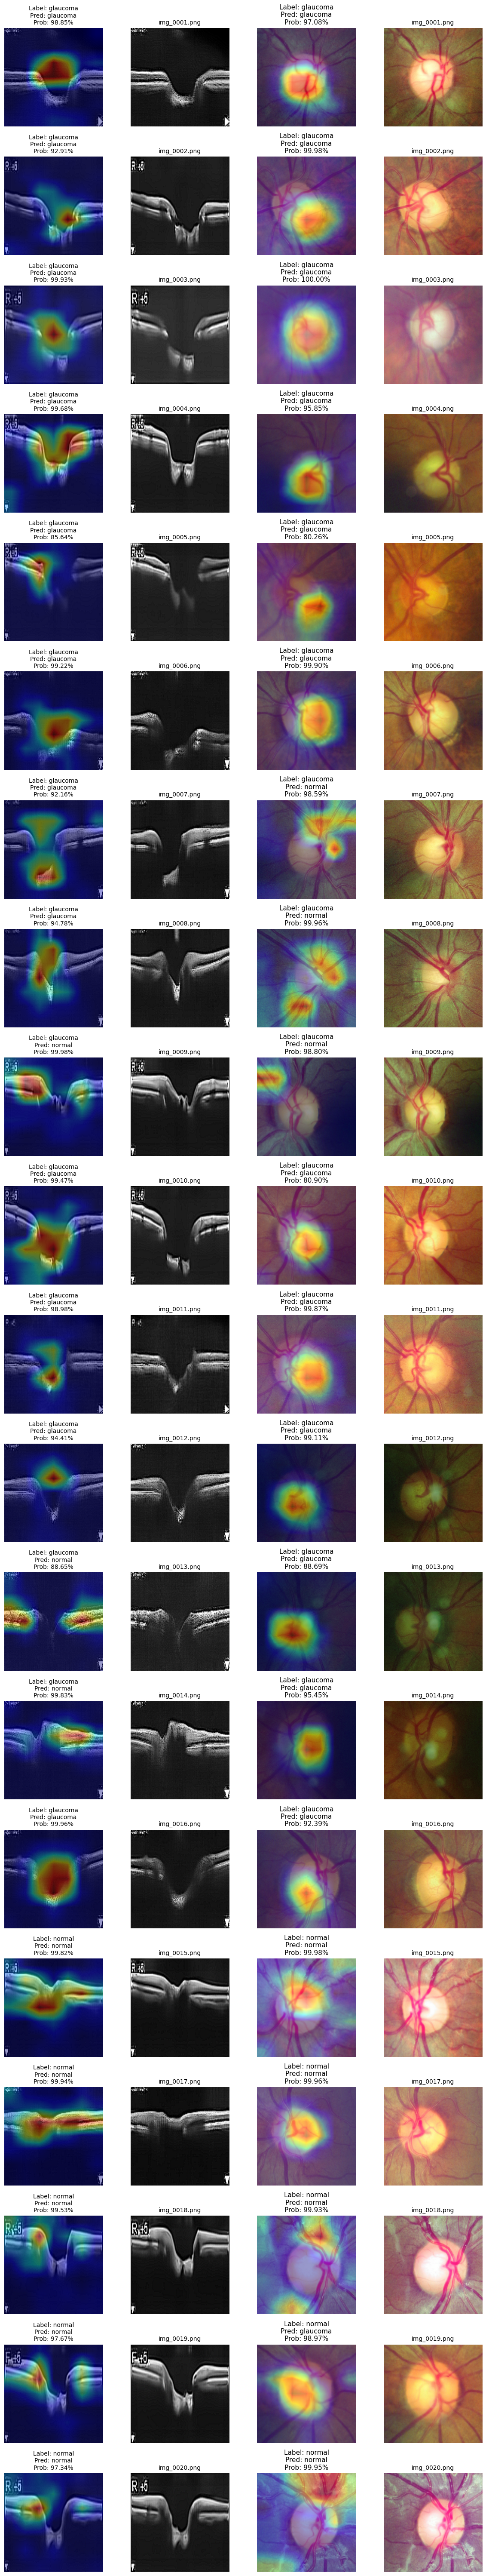

In [ ]:
visualize_cases_heatmaps(cfp_visualization_images.take(20), oct_visualization_images.take(20), grad_model_cfp,  grad_model_oct, class_names=class_names, img_names = image_names[0:])

num_figures: 12
(num_cols, num_rows): (4, 3)


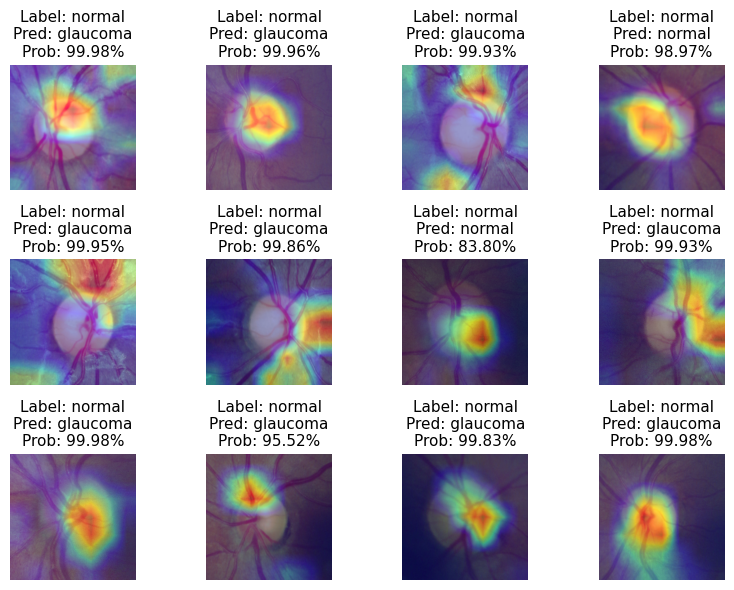

In [ ]:
visualize_gradcam(test_GRADCAM, grad_model, class_names=class_names)